In [1]:
pip install swig

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 34.8 MB/s eta 0:00:00


In [2]:
!pip install wheel
!pip install gymnasium[box2d]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.4/374.4 kB 13.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for box2d-py: filename=box2d_py-2.3.5-cp311-cp311-linux_x86_64.whl size=2379448 sha256=4bbe547d818b418d758955b256c852ea2cb83d6419799972a4299fa6d1f635e8
  Stored in directory: /root/.cache/pip/wheels/ab/f1/0c/d56f4a2bdd12bae0a0693ec33f2f0daadb5eb9753c78fa5308
Successfully built box2d-py


In [3]:
import gymnasium as gym
import numpy as np
import random
from collections import deque
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import clear_output

In [4]:


# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Check if CUDA is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define the DQN model architecture
class DQN(nn.Module):
    def __init__(self, state_size, action_size):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(state_size, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, action_size)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

In [5]:

# Define Replay Memory for experience replay
class ReplayMemory:
    def __init__(self, capacity):
        self.memory = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        experiences = random.sample(self.memory, batch_size)
        states, actions, rewards, next_states, dones = zip(*experiences)
        return np.vstack(states), actions, rewards, np.vstack(next_states), dones

    def __len__(self):
        return len(self.memory)

In [6]:

# Define the DQN agent
class DQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size

        # Define hyperparameters
        self.gamma = 0.99  # discount factor
        self.epsilon = 1.0  # exploration rate
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.learning_rate = 0.001
        self.batch_size = 64
        self.memory_size = 100000
        self.update_target_every = 100  # frequency to update target network

        # Create Q networks (policy and target)
        self.policy_net = DQN(state_size, action_size).to(device)
        self.target_net = DQN(state_size, action_size).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()  # target network is only used for inference

        # Define optimizer
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=self.learning_rate)

        # Create replay memory
        self.memory = ReplayMemory(self.memory_size)

        # Initialize step counter (for target network updates)
        self.step_counter = 0

    def select_action(self, state):
        # Epsilon-greedy action selection
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)

        state = torch.FloatTensor(state).unsqueeze(0).to(device)
        with torch.no_grad():
            action_values = self.policy_net(state)
        return torch.argmax(action_values).item()

    def learn(self):
        # Check if memory has enough samples
        if len(self.memory) < self.batch_size:
            return

        # Sample from memory
        states, actions, rewards, next_states, dones = self.memory.sample(self.batch_size)

        # Convert to PyTorch tensors
        states = torch.FloatTensor(states).to(device)
        actions = torch.LongTensor(actions).unsqueeze(1).to(device)
        rewards = torch.FloatTensor(rewards).unsqueeze(1).to(device)
        next_states = torch.FloatTensor(next_states).to(device)
        dones = torch.FloatTensor(dones).unsqueeze(1).to(device)

        # Get current Q values
        current_q_values = self.policy_net(states).gather(1, actions)

        # Compute target Q values
        with torch.no_grad():
            next_q_values = self.target_net(next_states).max(1, keepdim=True)[0]
        target_q_values = rewards + (self.gamma * next_q_values * (1 - dones))

        # Compute loss
        loss = F.smooth_l1_loss(current_q_values, target_q_values)

        # Optimize the model
        self.optimizer.zero_grad()
        loss.backward()
        # Clip gradients to stabilize training
        for param in self.policy_net.parameters():
            param.grad.data.clamp_(-1, 1)
        self.optimizer.step()

        # Update epsilon (exploration rate)
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

        # Update target network
        self.step_counter += 1
        if self.step_counter % self.update_target_every == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())

    def save_model(self, filename="lunar_lander_dqn.pth"):
        torch.save(self.policy_net.state_dict(), filename)

    def load_model(self, filename="lunar_lander_dqn.pth"):
        self.policy_net.load_state_dict(torch.load(filename, map_location=torch.device('cpu')))
        self.target_net.load_state_dict(self.policy_net.state_dict())


In [7]:


# Function to plot training progress
def plot_scores(scores, filename=None):
    clear_output(True)
    plt.figure(figsize=(10, 6))
    plt.plot(scores)
    plt.title('DQN Training Progress')
    plt.xlabel('Episode')
    plt.ylabel('Score')

    # Add a horizontal line at score 200 (considered "solved")
    plt.axhline(y=200, color='r', linestyle='-', alpha=0.3)
    plt.text(0, 210, 'Task considered solved when score >= 200', color='r')

    # Calculate and display moving average
    window_size = 100
    if len(scores) >= window_size:
        moving_avg = np.convolve(scores, np.ones(window_size)/window_size, mode='valid')
        plt.plot(range(window_size-1, len(scores)), moving_avg, color='orange')
        plt.text(len(scores)-1, moving_avg[-1], f'Moving Avg: {moving_avg[-1]:.2f}')

    if filename:
        plt.savefig(filename)
    plt.show()



In [8]:
def improved_reward_shaping(state, action, reward, next_state, info):
    """Apply reward shaping to encourage desired behavior."""
    # Original reward from environment
    shaped_reward = reward
    # Reward for being centered
    shaped_reward += 0.1 * (1 - abs(next_state[0]))  # Centering bonus
    # Penalties for velocities (quadratic)
    shaped_reward -= 0.03 * (abs(next_state[2]) ** 2)  # Horizontal velocity penalty
    shaped_reward -= 0.01 * (abs(next_state[3]) ** 2)  # Vertical velocity penalty
    shaped_reward -= 0.05 * (abs(next_state[4]) ** 1.5)  # Rotation penalty
    # Bonus for upright orientation
    shaped_reward += 0.05 * (1 - abs(next_state[4]))  # Angle penalty
    shaped_reward += 0.05 * (1 - abs(next_state[5]))  # Angular velocity penalty
    # Bonus for efficient fuel usage (negative reward for firing engines)
    if action in [1, 2, 3]:  # Engine actions
        shaped_reward -= 0.01  # Small penalty for using fuel
    return shaped_reward

In [9]:

# Modify the DQNAgent class to incorporate the reward shaping function
class DQNAgentWithShaping(DQNAgent):
    def __init__(self, state_size, action_size, use_reward_shaping=True):
        super().__init__(state_size, action_size)
        self.use_reward_shaping = use_reward_shaping

    def store_transition(self, state, action, reward, next_state, done, info=None):
        # Apply reward shaping if enabled
        if self.use_reward_shaping:
            shaped_reward = improved_reward_shaping(state, action, reward, next_state, info)
        else:
            shaped_reward = reward

        # Store the transition with the shaped reward
        self.memory.push(state, action, shaped_reward, next_state, done)


In [10]:
def train_lunar_lander_with_shaping(n_episodes=1500, max_steps=1000, target_score=250,
                                    solve_threshold=100, render=False, use_reward_shaping=True):
    # Create environment
    env = gym.make('LunarLander-v3')
    state_size = env.observation_space.shape[0]
    action_size = env.action_space.n

    # Create agent with reward shaping
    agent = DQNAgentWithShaping(state_size, action_size, use_reward_shaping)

    # Training variables
    scores = []
    avg_scores = []
    solved = False
    best_avg_score = float('-inf')  # Track best average score

    # Training loop
    for episode in range(n_episodes):
        state, info = env.reset()
        score = 0
        raw_score = 0  # Track original rewards for comparison

        for t in range(max_steps):
            # Select and perform an action
            action = agent.select_action(state)
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            # Store the transition (with or without reward shaping)
            agent.store_transition(state, action, reward, next_state, done, info)

            # Track original reward for logging
            raw_score += reward

            # Move to the next state
            state = next_state

            # Perform one step of the optimization
            agent.learn()

            # Check if episode is done
            if done:
                break

        # Record score for this episode (using raw score from environment for evaluation)
        scores.append(raw_score)

        # Calculate average score over last N episodes
        avg_score = np.mean(scores[-solve_threshold:]) if len(scores) >= solve_threshold else np.mean(scores)
        avg_scores.append(avg_score)

        # Print progress
        if episode % 10 == 0:
            print(f"Episode {episode}/{n_episodes}, Score: {raw_score:.2f}, Avg Score: {avg_score:.2f}, Epsilon: {agent.epsilon:.4f}")
            # Plot progress
            if episode % 100 == 0:
                plot_scores(scores)

        # Save model when average score improves
        if avg_score > best_avg_score:
            best_avg_score = avg_score
            agent.save_model("lunar_lander_dqn_best_weights.pth")
            print(f"New best average score: {best_avg_score:.2f} at episode {episode}. Model saved.")

        # Check if environment is solved
        if len(scores) >= solve_threshold and avg_score >= target_score and not solved:
            print(f"\nEnvironment solved in {episode} episodes! Average Score: {avg_score:.2f}")
            # Save the solved model (keeping this for backward compatibility)
            agent.save_model("lunar_lander_dqn_with_shaping_solved.pth")
            solved = True

    # Close environment
    env.close()

    # Plot final scores
    plot_scores(scores, "dqn_lunar_lander_with_shaping_training.png")

    return agent, scores

In [11]:
# Function to evaluate and visualize a trained agent
def evaluate_agent(agent, n_episodes=5, render=True):
    vectory = 0
    # Create environment
    env = gym.make('LunarLander-v3', render_mode='human' if render else None)

    for episode in range(n_episodes):
        state, _ = env.reset()
        total_reward = 0
        done = False

        while not done:
            # Select action with trained policy (no exploration)
            agent.epsilon = 0  # Turn off exploration
            action = agent.select_action(state)

            # Take action
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            total_reward += reward

            if render:
                env.render()
        if total_reward >= 200:
            vectory += 1

        print(f"Episode {episode+1}/{n_episodes}, Total Reward: {total_reward:.2f}")

    env.close()
    return vectory / n_episodes * 100

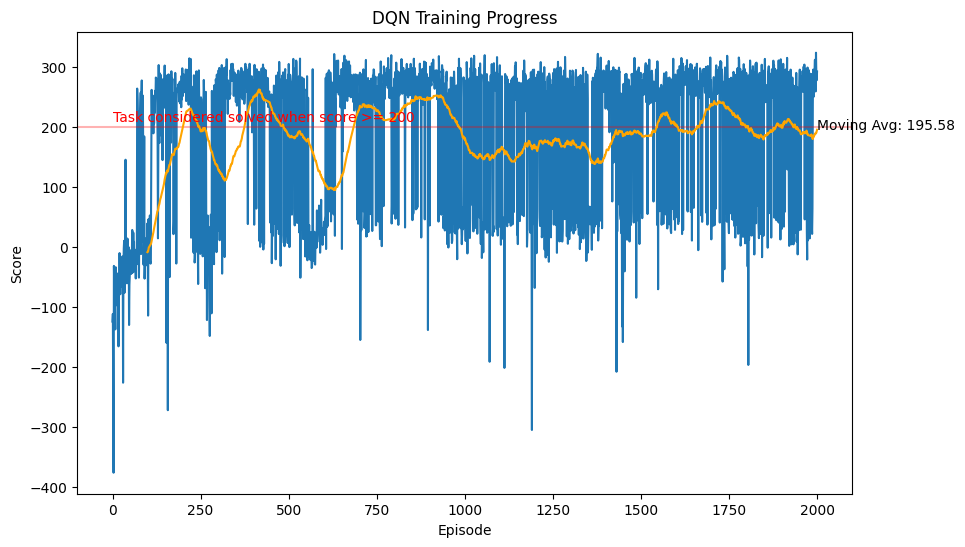

Episode 1/10, Total Reward: 268.67
Episode 2/10, Total Reward: 273.40
Episode 3/10, Total Reward: 300.52
Episode 4/10, Total Reward: 299.21
Episode 5/10, Total Reward: 306.59
Episode 6/10, Total Reward: 313.03
Episode 7/10, Total Reward: 261.70
Episode 8/10, Total Reward: 265.87
Episode 9/10, Total Reward: 260.02
Episode 10/10, Total Reward: 262.50
Win rate: 100.0%


In [ ]:
if __name__ == "__main__":
    # Train with reward shaping
    agent, scores = train_lunar_lander_with_shaping(n_episodes=2000)

    # Evaluate the trained agent
    win_rate = evaluate_agent(agent, n_episodes=10, render=True)
    print(f"Win rate: {win_rate}%")

In [12]:
env = gym.make('LunarLander-v3')
state_size = env.observation_space.shape[0]
action_size = env.action_space.n

In [13]:
import os
if os.path.exists("lunar_lander_dqn_with_shaping_solved.pth"):
    agent.load_model("lunar_lander_dqn_with_shaping_solved.pth")
else:
    print("Model file not found! Train the model first.")


Model file not found! Train the model first.


In [15]:
agent = DQNAgent(state_size, action_size)
agent.load_model('/content/lunar_lander_dqn_with_shaping_solved.pth')  # Adjust path if needed


In [ ]:
evaluate_agent(agent, n_episodes=5, render=True)


Episode 1/5, Total Reward: 263.53
Episode 2/5, Total Reward: 260.62
Episode 3/5, Total Reward: 288.34
Episode 4/5, Total Reward: 280.05
Episode 5/5, Total Reward: 268.14


100.0

In [19]:
accuracy=evaluate_agent(agent, n_episodes=10, render=True)
print(f"Accuracy: {accuracy:.2f}%")

Episode 1/10, Total Reward: 260.04
Episode 2/10, Total Reward: 284.94
Episode 3/10, Total Reward: 252.89
Episode 4/10, Total Reward: 254.64
Episode 5/10, Total Reward: 228.98
Episode 6/10, Total Reward: -24.66
Episode 7/10, Total Reward: 266.91
Episode 8/10, Total Reward: 270.83
Episode 9/10, Total Reward: 281.19
Episode 10/10, Total Reward: 223.82
Accuracy: 90.00%


In [ ]:
!pip install stable-baselines3[extra]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 112.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 84.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 92.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.5/184.5 kB 18.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstal

In [17]:
agent=DQNAgent(state_size, action_size)
agent.load_model("lunar_lander_dqn_with_shaping_solved.pth")

In [18]:
import os
import imageio
def evaluate_visualize_agent(agent, n_episodes=5, render=True, output_dir='recorded_episodes'):
  # Create clean output directory
    if os.path.exists(output_dir):
        for f in os.listdir(output_dir):
            os.remove(os.path.join(output_dir, f))
    else:
        os.makedirs(output_dir)

    # Create environment
    # env = gym.make('LunarLander-v3', render_mode='human' if render else None)
        # Set up environment
    env = gym.make("LunarLander-v3", render_mode='rgb_array')

    # Create output directory
    output_dir = "/content/videos"
    os.makedirs(output_dir, exist_ok=True)

    # Combined frames list
    frames = []

    # Run multiple episodes
    for episode in range(n_episodes):
        state, _ = env.reset()
        done = False
        total_reward = 0

        while not done:
            action = agent.select_action(state)
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_reward += reward

            # Capture frame (robust rendering)
            try:
                frame = env.render()
                if frame is not None:
                    frames.append(frame)
            except:
                print(f"Error capturing frame for episode {episode+1}. Skipping frame.")
                continue

        print(f"Episode {episode+1} finished with reward: {total_reward}")

    # Save all frames in one video
    if frames:
        video_path = os.path.join(output_dir, f"combined_episodes.mp4")
        imageio.mimsave(video_path, frames, fps=30)
        print(f"Saved combined video at {video_path}")
    else:
        print("No frames to save.")

    env.close()


In [ ]:
evaluate_visualize_agent(agent, n_episodes=10, render=True)

Episode 1 finished with reward: 287.84658165603423
Episode 2 finished with reward: 274.971799199413
Episode 3 finished with reward: 229.93445248200294
Episode 4 finished with reward: 48.71753943355736
Episode 5 finished with reward: 268.7542876764501
Episode 6 finished with reward: 281.1494532418045
Episode 7 finished with reward: 260.98906836214815
Episode 8 finished with reward: 21.043566370809003
Episode 9 finished with reward: 296.220292990281


Episode 10 finished with reward: 289.5145731969461
Saved combined video at /content/videos/combined_episodes.mp4


In [20]:
evaluate_visualize_agent(agent, n_episodes=10, render=True)

Episode 1 finished with reward: 255.79759965335063
Episode 2 finished with reward: -36.16935216106519
Episode 3 finished with reward: 248.61577759173446
Episode 4 finished with reward: 264.8269156337417
Episode 5 finished with reward: 276.4975852723483
Episode 6 finished with reward: 254.0095978793072
Episode 7 finished with reward: 176.7146087831876
Episode 8 finished with reward: 240.14898801150753
Episode 9 finished with reward: 274.7972754450536
Episode 10 finished with reward: 281.8225265496858


Saved combined video at /content/videos/combined_episodes.mp4


In [21]:
from IPython.display import HTML
from base64 import b64encode

mp4 = open('/content/videos/combined_episodes.mp4', 'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML(f'<video width=600 controls><source src="{data_url}" type="video/mp4"></video>')

In [ ]:
from IPython.display import HTML
from base64 import b64encode

mp4 = open('/content/videos/combined_episodes.mp4', 'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML(f'<video width=600 controls><source src="{data_url}" type="video/mp4"></video>')